In [21]:
import numpy as np
import nibabel as nib
import attrs
import matplotlib.pyplot as plt

from scipy.ndimage import (
    binary_dilation,
    distance_transform_edt,
    map_coordinates,
)


@attrs.define
class NiftiImage:
    path: str
    spacing: tuple[float, float, float] = None
    canonical: bool = True
    img: nib.Nifti1Image = attrs.field(init=False)
    array: np.ndarray = attrs.field(init=False)

    def __attrs_post_init__(self):
        img = nib.load(self.path)
        if self.canonical:
            img = nib.as_closest_canonical(img)
        self.img = img
        self.array = np.asanyarray(self.img.dataobj)
        if self.spacing is None:
            self.spacing = tuple(float(x) for x in self.img.header.get_zooms()[:3])

    def update(self):
        self.img = nib.Nifti1Image(self.array, self.img.affine, self.img.header)

    def save(self, out_path=None):
        if out_path is None:
            out_path = self.path
        self.update()
        nib.save(self.img, out_path)
        return out_path


def compute_outward_normals(tc_mask, spacing):
    tc_mask = tc_mask.astype(bool)
    spacing = np.asarray(spacing, dtype=float)

    dist_in = distance_transform_edt(tc_mask, sampling=spacing)
    grads = np.gradient(dist_in, *spacing, edge_order=1)
    grad = np.stack(grads, axis=-1)

    outward = -grad
    mag = np.linalg.norm(outward, axis=-1, keepdims=True)

    outward_unit = np.divide(
        outward,
        np.maximum(mag, 1e-12),
        out=np.zeros_like(outward),
        where=mag > 1e-12,
    )
    return outward_unit


def transition_zone_thickness(
    t1ce_pth,
    seg_pth,
    step_vox=0.25,
    max_dist_mm=80.0,
    do_plot=True,
    save_plot_path=None,
    band_mode="edema_neighborhood",
    crop_padding=15,
):
    t1ce_img = NiftiImage(t1ce_pth, canonical=True)
    t1ce_array = t1ce_img.array.astype(np.float32)

    seg_img = NiftiImage(seg_pth, canonical=True)
    seg_array = seg_img.array.astype(np.int16)

    # canonical orientation: treat as (x, y, z)
    spacing = np.asarray(seg_img.spacing, dtype=float)

    tc_mask = np.isin(seg_array, [1, 3, 4]).astype(bool)
    ed_mask = np.isin(seg_array, [2]).astype(bool)

    # choose axial slice with largest tumor-core area
    tc_area_per_axial_slice = tc_mask.sum(axis=(0, 1))
    if np.all(tc_area_per_axial_slice == 0):
        return {
            "transition_zone_thickness_in_mm": np.nan,
            "axial_slice_index": None,
            "n_boundary_voxels": 0,
            "n_successful_rays": 0,
            "edema_intensity_band": (np.nan, np.nan),
        }

    z_best = int(np.argmax(tc_area_per_axial_slice))

    def nn_mask(mask, p):
        ix, iy, iz = np.round(p).astype(int)
        if (
            ix < 0 or iy < 0 or iz < 0
            or ix >= mask.shape[0]
            or iy >= mask.shape[1]
            or iz >= mask.shape[2]
        ):
            return False
        return bool(mask[ix, iy, iz])

    # tumor-core boundary adjacent to edema
    edema_dil = binary_dilation(ed_mask, iterations=1)
    boundary = tc_mask & edema_dil & ~ed_mask
    boundary_coords = np.argwhere(boundary)

    if boundary_coords.size == 0:
        return {
            "transition_zone_thickness_in_mm": np.nan,
            "axial_slice_index": z_best,
            "n_boundary_voxels": 0,
            "n_successful_rays": 0,
            "edema_intensity_band": (np.nan, np.nan),
        }

    # robust edema intensity band
    ed_vals = t1ce_array[ed_mask]
    if ed_vals.size == 0:
        return {
            "transition_zone_thickness_in_mm": np.nan,
            "axial_slice_index": z_best,
            "n_boundary_voxels": int(len(boundary_coords)),
            "n_successful_rays": 0,
            "edema_intensity_band": (np.nan, np.nan),
        }

    ed_med = np.median(ed_vals)
    # mad = np.median(np.abs(ed_vals - ed_med)) + 1e-6
    # abs_band = max(1.4826 * mad, 1e-6)
    # ed_lower = max(ed_med - abs_band, float(np.min(ed_vals)))
    # ed_upper = min(ed_med + abs_band, float(np.max(ed_vals)))
    p40, p60 = np.percentile(ed_vals, [40, 60])
    ed_lower = float(p40)
    ed_upper = float(p60)

    outward_normals = compute_outward_normals(tc_mask, spacing)

    thicknesses = []
    ray_records = []

    for xyz in boundary_coords:
        x0, y0, z0 = xyz.astype(float)

        u = outward_normals[tuple(xyz)].astype(float)
        nu = np.linalg.norm(u)
        if nu < 1e-8:
            continue
        u = u / nu

        mm_per_vox_step = np.linalg.norm(u * spacing)
        if mm_per_vox_step == 0:
            continue

        n_steps = int(np.ceil(max_dist_mm / (step_vox * mm_per_vox_step)))

        # true boundary point for display
        p_boundary = np.array([x0, y0, z0], dtype=float)

        # start sampling just outside tumor core
        p0 = p_boundary + u * step_vox

        prev_int = map_coordinates(
            t1ce_array,
            [[p0[0]], [p0[1]], [p0[2]]],
            order=1,
            mode="nearest",
        )[0]
        prev_d_mm = 0.0
        sampled_points = [p0.copy()]

        # accept zero only if immediately in edema and in edema band
        in_edema0 = nn_mask(ed_mask, p0)
        if in_edema0 and (ed_lower <= prev_int <= ed_upper):
            thicknesses.append(0.0)
            if int(xyz[2]) == z_best:
                ray_records.append(
                    {
                        "start": p_boundary.copy(),
                        "stop": p0.copy(),
                        "path": np.array(sampled_points, dtype=float),
                        "thickness_mm": 0.0,
                    }
                )
            continue

        found_hit = False

        for k in range(1, n_steps + 1):
            p = p0 + u * (k * step_vox)
            sampled_points.append(p.copy())

            I = map_coordinates(
                t1ce_array,
                [[p[0]], [p[1]], [p[2]]],
                order=1,
                mode="nearest",
            )[0]

            d_mm = k * step_vox * mm_per_vox_step

            in_tc = nn_mask(tc_mask, p)
            in_edema = nn_mask(ed_mask, p)

            # once outside tumor core, ray is only valid while still inside edema
            if (not in_tc) and (not in_edema):
                break

            # valid stop must occur inside edema
            if in_edema and (ed_lower <= I <= ed_upper):
                p_hit = p.copy()

                if abs(I - prev_int) > 1e-6:
                    if prev_int > ed_upper and I <= ed_upper:
                        target = ed_upper
                    elif prev_int < ed_lower and I >= ed_lower:
                        target = ed_lower
                    else:
                        target = ed_med

                    alpha = (target - prev_int) / (I - prev_int + 1e-12)
                    alpha = float(np.clip(alpha, 0.0, 1.0))
                    d_mm = prev_d_mm + alpha * (d_mm - prev_d_mm)

                    p_prev = sampled_points[-2]
                    p_hit = p_prev + alpha * (p - p_prev)

                thicknesses.append(float(d_mm))
                found_hit = True

                if int(xyz[2]) == z_best:
                    ray_records.append(
                        {
                            "start": p_boundary.copy(),
                            "stop": p_hit.copy(),
                            "path": np.array(sampled_points, dtype=float),
                            "thickness_mm": float(d_mm),
                        }
                    )
                break

            prev_int, prev_d_mm = I, d_mm

        if (not found_hit) and int(xyz[2]) == z_best:
            ray_records.append(
                {
                    "start": p_boundary.copy(),
                    "stop": None,
                    "path": np.array(sampled_points, dtype=float),
                    "thickness_mm": np.nan,
                }
            )

    result = {
        "transition_zone_thickness_in_mm": float(np.nanmedian(thicknesses)) if len(thicknesses) else np.nan,
        "axial_slice_index": z_best,
        "n_boundary_voxels": int(len(boundary_coords)),
        "n_successful_rays": int(np.sum(np.isfinite(thicknesses))),
        "edema_intensity_band": (float(ed_lower), float(ed_upper)),
    }

    if do_plot:
        plot_transition_zone_slice(
            t1ce_slice=t1ce_array[:, :, z_best],
            tc_slice=tc_mask[:, :, z_best],
            ed_slice=ed_mask[:, :, z_best],
            boundary_slice=boundary[:, :, z_best],
            ray_records=ray_records,
            z_index=z_best,
            ed_lower=ed_lower,
            ed_upper=ed_upper,
            band_mode=band_mode,
            save_path=save_plot_path,
            crop_padding=crop_padding,
        )

    return result


def plot_transition_zone_slice(
    t1ce_slice,
    tc_slice,
    ed_slice,
    boundary_slice,
    ray_records,
    z_index,
    ed_lower,
    ed_upper,
    band_mode="edema_neighborhood",
    save_path=None,
    crop_padding=15,
):
    fig, ax = plt.subplots(figsize=(8, 8))

    if band_mode == "edema_only":
        support_mask = ed_slice
    else:
        support_mask = binary_dilation(ed_slice, iterations=1) & (~tc_slice)

    band_mask_strict = (
        (t1ce_slice >= ed_lower) &
        (t1ce_slice <= ed_upper) &
        support_mask
    )

    crop_mask = tc_slice | ed_slice | boundary_slice | band_mask_strict

    for rec in ray_records:
        path = rec["path"]
        if path is not None and len(path) > 0:
            xs = np.clip(np.round(path[:, 0]).astype(int), 0, t1ce_slice.shape[0] - 1)
            ys = np.clip(np.round(path[:, 1]).astype(int), 0, t1ce_slice.shape[1] - 1)
            crop_mask[xs, ys] = True

        stop = rec["stop"]
        if stop is not None:
            sx = int(np.clip(round(stop[0]), 0, t1ce_slice.shape[0] - 1))
            sy = int(np.clip(round(stop[1]), 0, t1ce_slice.shape[1] - 1))
            crop_mask[sx, sy] = True

    coords = np.argwhere(crop_mask)
    if coords.size == 0:
        x_min, y_min = 0, 0
        x_max, y_max = t1ce_slice.shape[0], t1ce_slice.shape[1]
    else:
        x_min = max(int(coords[:, 0].min()) - crop_padding, 0)
        x_max = min(int(coords[:, 0].max()) + crop_padding + 1, t1ce_slice.shape[0])
        y_min = max(int(coords[:, 1].min()) - crop_padding, 0)
        y_max = min(int(coords[:, 1].max()) + crop_padding + 1, t1ce_slice.shape[1])

    t1ce_crop = t1ce_slice[x_min:x_max, y_min:y_max]
    boundary_crop = boundary_slice[x_min:x_max, y_min:y_max]
    band_crop = band_mask_strict[x_min:x_max, y_min:y_max]

    ax.imshow(t1ce_crop.T, cmap="gray", origin="lower")

    band_overlay = np.zeros((band_crop.shape[1], band_crop.shape[0], 4), dtype=float)
    band_overlay[band_crop.T] = [1.0, 0.0, 1.0, 0.20]
    ax.imshow(band_overlay, origin="lower")

    bx, by = np.where(boundary_crop)
    if len(bx) > 0:
        ax.scatter(
            bx,
            by,
            s=10,
            c="yellow",
            marker="o",
            linewidths=0,
            label="Boundary (ray starts)",
        )

    shown_transition = False
    shown_stop = False
    shown_failed = False

    for rec in ray_records:
        path = rec["path"]
        start = rec["start"]
        stop = rec["stop"]

        xs = path[:, 0] - x_min
        ys = path[:, 1] - y_min

        if stop is not None:
            ax.plot(
                xs,
                ys,
                color="orange",
                linewidth=1.2,
                alpha=0.8,
                label="Transition band along rays" if not shown_transition else None,
            )
            shown_transition = True

            ax.scatter(
                stop[0] - x_min,
                stop[1] - y_min,
                s=30,
                c="lime",
                marker="x",
                linewidths=1.5,
                label="Ray stop points" if not shown_stop else None,
            )
            shown_stop = True
        else:
            ax.plot(
                xs,
                ys,
                color="orange",
                linewidth=0.9,
                alpha=0.35,
                linestyle="--",
                label="Rays without stop" if not shown_failed else None,
            )
            shown_failed = True

        ax.scatter(
            start[0] - x_min,
            start[1] - y_min,
            s=10,
            c="yellow",
            marker="o",
            linewidths=0,
        )

    ax.scatter([], [], s=40, c="magenta", marker="s", label="Strict edema-intensity band")

    ax.set_title(f"Transition-zone rays on axial slice z={z_index}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc="upper right", frameon=True)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

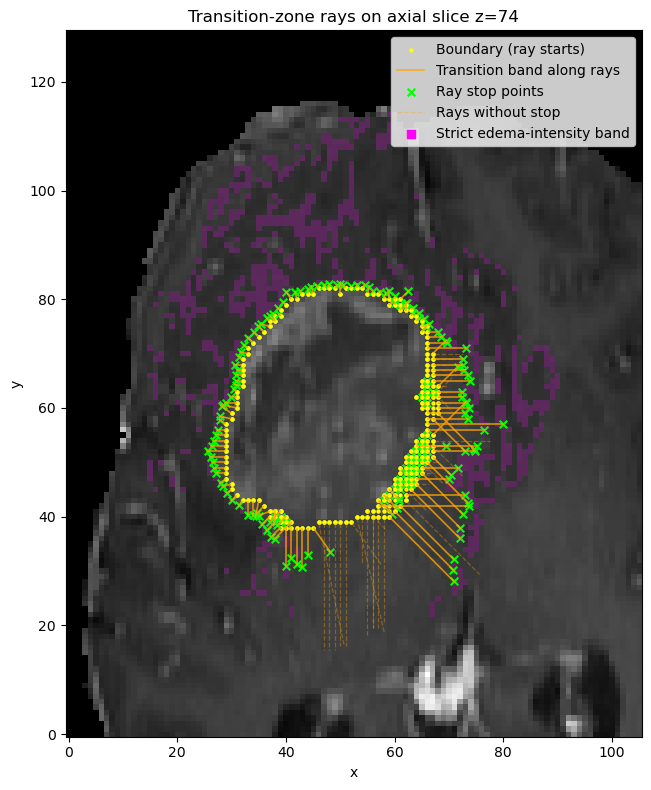

{'transition_zone_thickness_in_mm': 2.4283280996824934, 'axial_slice_index': 74, 'n_boundary_voxels': 5569, 'n_successful_rays': 4381, 'edema_intensity_band': (1755.0, 1919.0)}


In [22]:
if __name__ == "__main__":
    t1ce_pth = "/Users/muqeemmmm/Dataset/BraTS2021_00002/BraTS2021_00002_t1ce.nii.gz"
    seg_pth = "/Users/muqeemmmm/Dataset/BraTS2021_00002/BraTS2021_00002_seg.nii.gz"

    result = transition_zone_thickness(
        t1ce_pth=t1ce_pth,
        seg_pth=seg_pth,
        step_vox=0.25,
        max_dist_mm=80.0,
        do_plot=True,
        save_plot_path="transition_zone_axial_slice.png",
    )

    print(result)